<a href="https://colab.research.google.com/github/Sadith14/ALGORITMOS-DE-ENJAMBRE-EN-EL-APRENDIZAJE-M-QUINA/blob/main/ABC_Feature_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Selection con Algoritmo ABC (Artificial Bee Colony)
Dataset: Mushroom Classification (UCI)


## 1. Instalación e Importación de Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, random, time

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)
print('Librerias importadas correctamente')

Librerias importadas correctamente


## 2. Carga del Dataset

In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cargar dataset
path = '/content/drive/MyDrive/APRENDIZAJE MAQUINA/mushrooms.csv'

try:
    df = pd.read_csv(path)
    print('Dataset cargado desde Google Drive')
except Exception as e:
    print(f'Error cargando desde Drive: {e}')
    print('Cargando desde UCI...')
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data'
    cols = ['class','cap-shape','cap-surface','cap-color','bruises','odor',
            'gill-attachment','gill-spacing','gill-size','gill-color',
            'stalk-shape','stalk-root','stalk-surface-above-ring',
            'stalk-surface-below-ring','stalk-color-above-ring',
            'stalk-color-below-ring','veil-type','veil-color','ring-number',
            'ring-type','spore-print-color','population','habitat']
    df = pd.read_csv(url, header=None, names=cols)
    print('Dataset cargado desde UCI')

print(f'Dimensiones: {df.shape}')
df.head()

Dataset cargado desde Google Drive
Dimensiones: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
print('Distribucion de clases:')
print(df['class'].value_counts())
print(f"Venenosos: {(df['class']=='p').mean()*100:.1f}%")
print(f"Comestibles: {(df['class']=='e').mean()*100:.1f}%")

Distribucion de clases:
class
e    4208
p    3916
Name: count, dtype: int64
Venenosos: 48.2%
Comestibles: 51.8%


## 3. Preprocesamiento

In [ ]:
df_enc = df.copy()

# Reemplazar '?' con la moda
for col in df_enc.columns:
    df_enc[col] = df_enc[col].replace('?', df_enc[col].mode()[0])

# Label Encoding
le = LabelEncoder()
for col in df_enc.columns:
    df_enc[col] = le.fit_transform(df_enc[col])

X = df_enc.drop('class', axis=1).values
y = df_enc['class'].values
feature_names = list(df_enc.drop('class', axis=1).columns)
n_features = X.shape[1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Caracteristicas: {n_features}')
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Features: {feature_names}')

Caracteristicas: 22
Train: 6499 | Test: 1625
Features: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


## 4. Algoritmo ABC para Feature Selection

### Ciclo del Algoritmo

```
1. REPRESENTACION  → vector binario [0,1,1,0,...] = features activas
2. INICIALIZACION  → N soluciones aleatorias (fuentes de alimento)
3. FITNESS         → accuracy_CV - alpha * (n_sel / n_total)
4. ABEJA EMPLEADA  → explora vecindad (bit-flip)
5. ABEJA OBSERVAD. → seleccion por ruleta, mejora fuentes
6. ABEJA EXPLOR.   → abandona fuentes estancadas
7. FINALIZACION    → retorna mejor vector binario
```

### Funcion de Fitness
$$f(s) = Accuracy_{CV}(s) - alpha * (|s| / D)$$

In [ ]:
class ABCFeatureSelection:
    """
    Artificial Bee Colony para Feature Selection Binario.
    """

    def __init__(self, n_bees=20, max_iter=50, limit=8,
                 alpha=0.05, classifier=None, cv=5, verbose=True):
        self.n_bees = n_bees
        self.max_iter = max_iter
        self.limit = limit
        self.alpha = alpha
        self.cv = cv
        self.verbose = verbose
        self.classifier = classifier or DecisionTreeClassifier(random_state=42)
        self.history_best = []
        self.history_mean = []
        self.history_nfeat = []
        self.history_sols = []

    # PASO 1: REPRESENTACION DE LA PARTICULA
    def _nueva_fuente(self, n):
        s = np.random.randint(0, 2, n)
        if s.sum() == 0:
            s[np.random.randint(n)] = 1
        return s

    # PASO 2: FUNCION DE APTITUD
    def _fitness(self, sol, X, y):
        idx = np.where(sol == 1)[0]
        if len(idx) == 0:
            return 0.0
        Xs = X[:, idx]
        scores = cross_val_score(
            self.classifier, Xs, y,
            cv=StratifiedKFold(n_splits=self.cv, shuffle=True, random_state=42),
            scoring='accuracy')
        return scores.mean() - self.alpha * (len(idx) / len(sol))

    # OPERADOR DE MUTACION: bit-flip
    def _vecino(self, sol):
        v = sol.copy()
        i = np.random.randint(len(v))
        v[i] = 1 - v[i]
        if v.sum() == 0:
            v[i] = 1
        return v

    # CICLO ABC COMPLETO
    def fit(self, X, y):
        n = X.shape[1]
        if self.verbose:
            print('='*55)
            print(f'ABC INICIO | bees={self.n_bees} | iter={self.max_iter} | limit={self.limit}')
            print('='*55)

        # INICIALIZACION DEL ENJAMBRE
        fuentes = [self._nueva_fuente(n) for _ in range(self.n_bees)]
        fitness = [self._fitness(s, X, y) for s in fuentes]
        contad  = [0] * self.n_bees

        mejor_idx = np.argmax(fitness)
        mejor_sol = fuentes[mejor_idx].copy()
        mejor_fit = fitness[mejor_idx]

        if self.verbose:
            print(f'Init | best_fit={mejor_fit:.4f} | features={int(mejor_sol.sum())}/{n}\n')

        for it in range(self.max_iter):

            # FASE ABEJA EMPLEADA
            for i in range(self.n_bees):
                v = self._vecino(fuentes[i])
                fv = self._fitness(v, X, y)
                if fv > fitness[i]:
                    fuentes[i], fitness[i], contad[i] = v, fv, 0
                else:
                    contad[i] += 1

            # FASE ABEJA OBSERVADORA (ruleta)
            fa = np.array(fitness)
            fa_adj = fa - fa.min() + 1e-10
            probs = fa_adj / fa_adj.sum()
            for _ in range(self.n_bees):
                i = np.random.choice(self.n_bees, p=probs)
                v = self._vecino(fuentes[i])
                fv = self._fitness(v, X, y)
                if fv > fitness[i]:
                    fuentes[i], fitness[i], contad[i] = v, fv, 0
                else:
                    contad[i] += 1

            # FASE ABEJA EXPLORADORA
            for i in range(self.n_bees):
                if contad[i] >= self.limit:
                    fuentes[i] = self._nueva_fuente(n)
                    fitness[i] = self._fitness(fuentes[i], X, y)
                    contad[i]  = 0

            # ACTUALIZAR MEJOR GLOBAL
            idx_best = np.argmax(fitness)
            if fitness[idx_best] > mejor_fit:
                mejor_fit = fitness[idx_best]
                mejor_sol = fuentes[idx_best].copy()

            self.history_best.append(mejor_fit)
            self.history_mean.append(np.mean(fitness))
            self.history_nfeat.append(int(mejor_sol.sum()))
            self.history_sols.append(mejor_sol.copy())

            if self.verbose and (it % 10 == 0 or it == self.max_iter - 1):
                print(f'Iter {it+1:3d}/{self.max_iter} | '
                      f'best={mejor_fit:.4f} | mean={np.mean(fitness):.4f} | '
                      f'feats={int(mejor_sol.sum())}/{n}')

        # FINALIZACION
        self.best_solution_ = mejor_sol
        self.best_fitness_  = mejor_fit
        self.selected_idx_  = np.where(mejor_sol == 1)[0]

        if self.verbose:
            print('\n' + '='*55)
            print(f'RESULTADO: fitness={mejor_fit:.4f} | '
                  f'features={len(self.selected_idx_)}/{n} | '
                  f'reduccion={100*(1-len(self.selected_idx_)/n):.1f}%')
            print('='*55)
        return self

    def transform(self, X):
        return X[:, self.selected_idx_]

print('Clase ABCFeatureSelection definida OK')

Clase ABCFeatureSelection definida OK


## 5. Ejecución del ABC

In [ ]:
print('Iniciando ABC...\n')
t0 = time.time()

abc = ABCFeatureSelection(
    n_bees=20, max_iter=50, limit=8, alpha=0.05,
    classifier=DecisionTreeClassifier(max_depth=10, random_state=42),
    cv=5, verbose=True)

abc.fit(X_train, y_train)
print(f'\nTiempo: {time.time()-t0:.1f}s')

Iniciando ABC...

ABC INICIO | bees=20 | iter=50 | limit=8
Init | best_fit=0.9773 | features=10/22

Iter   1/50 | best=0.9795 | mean=0.9691 | feats=9/22
Iter  11/50 | best=0.9866 | mean=0.9769 | feats=5/22
Iter  21/50 | best=0.9886 | mean=0.9770 | feats=5/22
Iter  31/50 | best=0.9888 | mean=0.9757 | feats=4/22
Iter  41/50 | best=0.9888 | mean=0.9768 | feats=4/22
Iter  50/50 | best=0.9901 | mean=0.9799 | feats=4/22

RESULTADO: fitness=0.9901 | features=4/22 | reduccion=81.8%

Tiempo: 75.7s


## 6. Resultados

In [ ]:
feats_sel = [feature_names[i] for i in abc.selected_idx_]
feats_des = [f for f in feature_names if f not in feats_sel]

print('CARACTERISTICAS SELECCIONADAS:')
for i, f in enumerate(feats_sel, 1):
    print(f'  {i:2d}. {f}')

print(f'\nCARACTERISTICAS DESCARTADAS ({len(feats_des)}):')
for f in feats_des:
    print(f'  - {f}')

CARACTERISTICAS SELECCIONADAS:
   1. bruises
   2. odor
   3. stalk-surface-below-ring
   4. habitat

CARACTERISTICAS DESCARTADAS (18):
  - cap-shape
  - cap-surface
  - cap-color
  - gill-attachment
  - gill-spacing
  - gill-size
  - gill-color
  - stalk-shape
  - stalk-root
  - stalk-surface-above-ring
  - stalk-color-above-ring
  - stalk-color-below-ring
  - veil-type
  - veil-color
  - ring-number
  - ring-type
  - spore-print-color
  - population


In [ ]:
# Modelo con TODAS las features
clf_full = DecisionTreeClassifier(max_depth=10, random_state=42)
clf_full.fit(X_train, y_train)
acc_full = accuracy_score(y_test, clf_full.predict(X_test))

# Modelo con features ABC
X_tr_abc = abc.transform(X_train)
X_te_abc = abc.transform(X_test)
clf_abc = DecisionTreeClassifier(max_depth=10, random_state=42)
clf_abc.fit(X_tr_abc, y_train)
y_pred_abc = clf_abc.predict(X_te_abc)
acc_abc = accuracy_score(y_test, y_pred_abc)

print('='*50)
print(f'Todas las features ({n_features}):  Accuracy = {acc_full:.4f}')
print(f'Seleccion ABC     ({len(abc.selected_idx_)}):  Accuracy = {acc_abc:.4f}')
print(f'Reduccion: {(1-len(abc.selected_idx_)/n_features)*100:.1f}%')
print(f'Cambio accuracy: {(acc_abc-acc_full)*100:+.3f}%')
print('='*50)
print()
print(classification_report(y_test, y_pred_abc,
      target_names=['Comestible(e)','Venenoso(p)']))

Todas las features (22):  Accuracy = 1.0000
Seleccion ABC     (4):  Accuracy = 0.9982
Reduccion: 81.8%
Cambio accuracy: -0.185%

               precision    recall  f1-score   support

Comestible(e)       1.00      1.00      1.00       842
  Venenoso(p)       1.00      1.00      1.00       783

     accuracy                           1.00      1625
    macro avg       1.00      1.00      1.00      1625
 weighted avg       1.00      1.00      1.00      1625



## 7. Visualizaciones

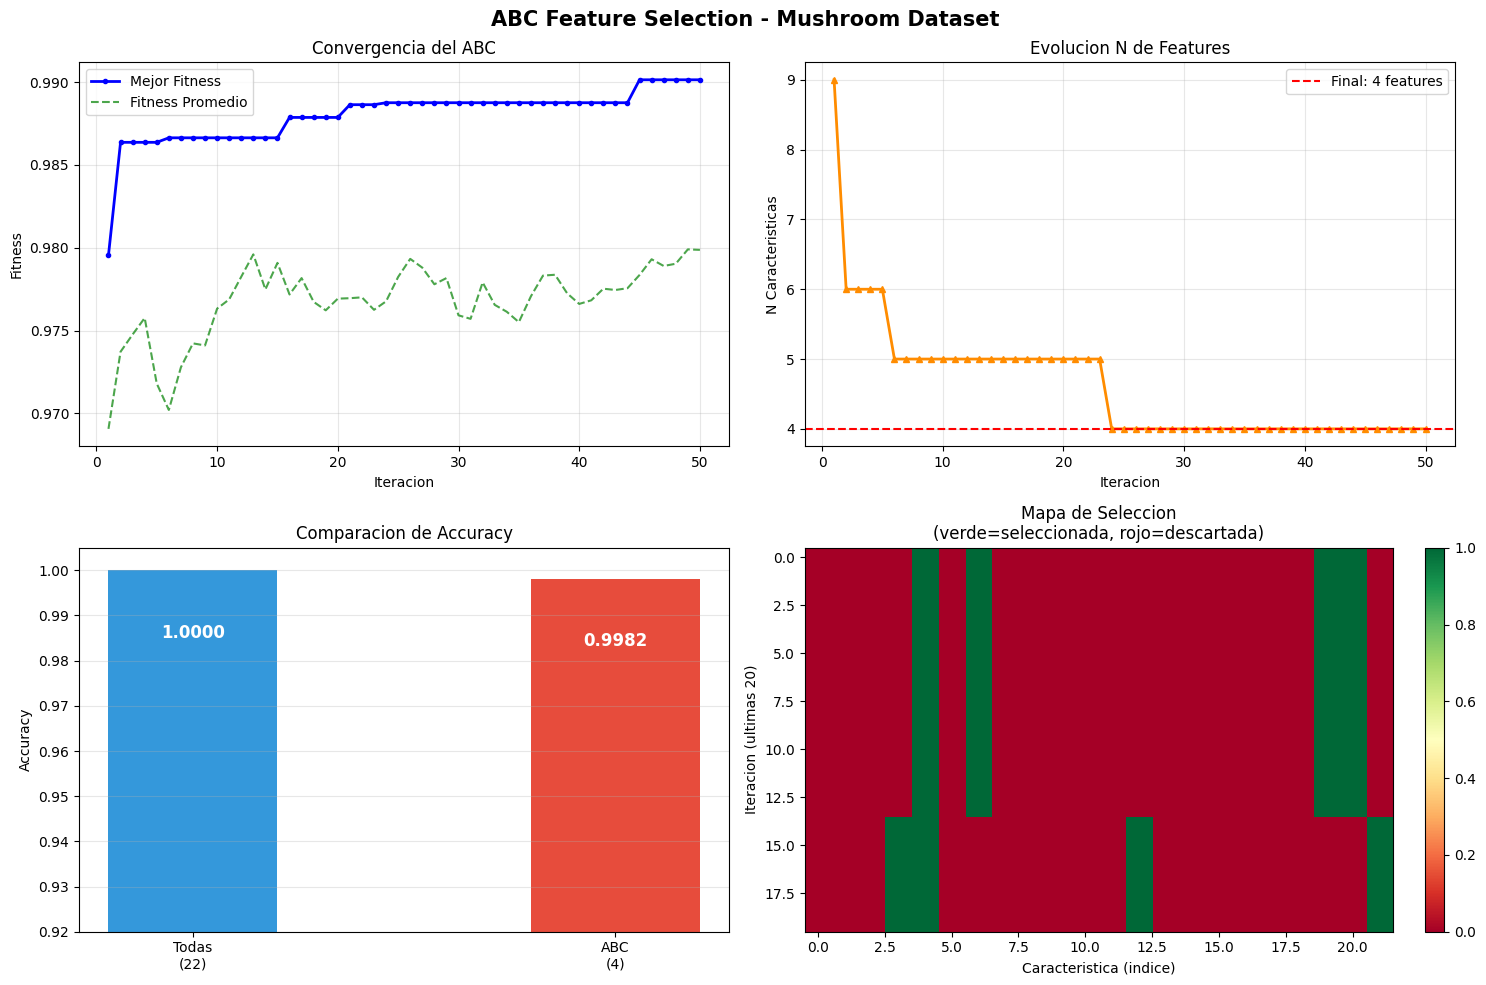

Figura guardada: abc_mushrooms.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('ABC Feature Selection - Mushroom Dataset', fontsize=15, fontweight='bold')

iters = range(1, len(abc.history_best) + 1)

# Convergencia
ax = axes[0,0]
ax.plot(iters, abc.history_best, 'b-o', ms=3, lw=2, label='Mejor Fitness')
ax.plot(iters, abc.history_mean, 'g--', ms=3, lw=1.5, alpha=0.7, label='Fitness Promedio')
ax.set_xlabel('Iteracion'); ax.set_ylabel('Fitness')
ax.set_title('Convergencia del ABC'); ax.legend(); ax.grid(alpha=0.3)

# N features
ax = axes[0,1]
ax.plot(iters, abc.history_nfeat, color='darkorange', lw=2, marker='^', ms=4)
ax.axhline(len(abc.selected_idx_), color='red', linestyle='--',
           label=f'Final: {len(abc.selected_idx_)} features')
ax.set_xlabel('Iteracion'); ax.set_ylabel('N Caracteristicas')
ax.set_title('Evolucion N de Features'); ax.legend(); ax.grid(alpha=0.3)

# Comparacion accuracy
ax = axes[1,0]
bars = ax.bar(['Todas\n(22)', f'ABC\n({len(abc.selected_idx_)})'],
              [acc_full, acc_abc], color=['#3498db','#e74c3c'], width=0.4)
for bar, v in zip(bars, [acc_full, acc_abc]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()-0.015,
            f'{v:.4f}', ha='center', fontweight='bold', color='white', fontsize=12)
ax.set_ylim(0.92, 1.005); ax.set_ylabel('Accuracy')
ax.set_title('Comparacion de Accuracy'); ax.grid(axis='y', alpha=0.3)

# Mapa de calor seleccion
ax = axes[1,1]
sol_mat = np.array(abc.history_sols[-20:])
im = ax.imshow(sol_mat, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xlabel('Caracteristica (indice)'); ax.set_ylabel('Iteracion (ultimas 20)')
ax.set_title('Mapa de Seleccion\n(verde=seleccionada, rojo=descartada)')
plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig('abc_mushrooms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: abc_mushrooms.png')

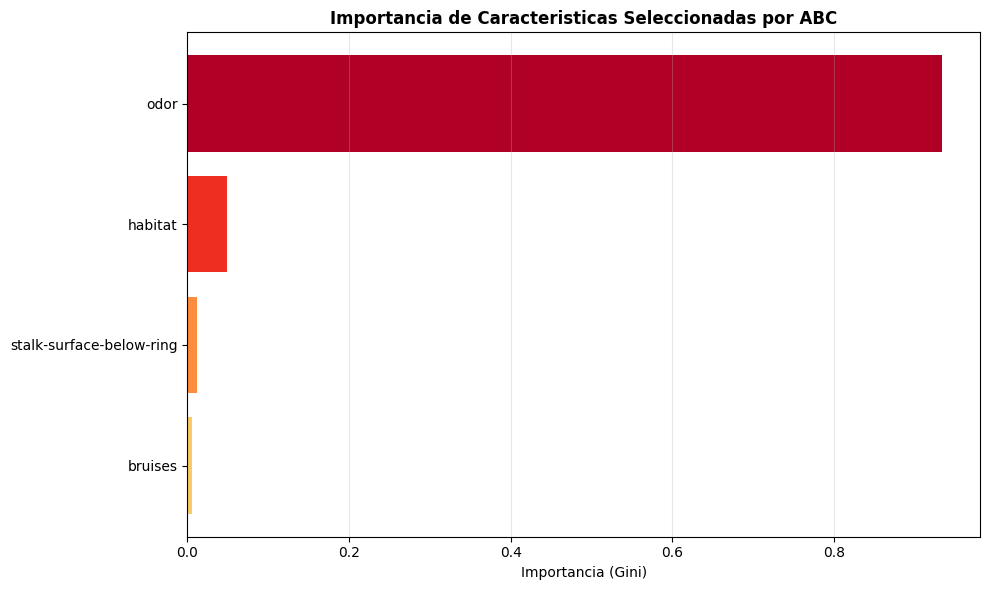

In [ ]:
# Importancia de features seleccionadas
importancias = clf_abc.feature_importances_
idx_ord = np.argsort(importancias)
nombres_ord = [feats_sel[i] for i in idx_ord]
imp_ord = importancias[idx_ord]

fig, ax = plt.subplots(figsize=(10, 6))
colores = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(nombres_ord)))
ax.barh(range(len(nombres_ord)), imp_ord, color=colores)
ax.set_yticks(range(len(nombres_ord)))
ax.set_yticklabels(nombres_ord, fontsize=10)
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Importancia de Caracteristicas Seleccionadas por ABC', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('abc_importancia.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Resumen Final

In [ ]:
print()
print('RESUMEN FINAL - ABC FEATURE SELECTION')
print('='*55)
print(f'Dataset         : Mushroom UCI ({len(df)} instancias)')
print(f'Algoritmo       : Artificial Bee Colony (ABC)')
print(f'Clasificador    : Decision Tree')
print()
print('PARAMETROS ABC')
print(f'  n_bees  : {abc.n_bees}')
print(f'  max_iter: {abc.max_iter}')
print(f'  limit   : {abc.limit}')
print(f'  alpha   : {abc.alpha}')
print()
print('RESULTADOS')
print(f'  Features originales  : {n_features}')
print(f'  Features seleccionadas: {len(abc.selected_idx_)}')
print(f'  Reduccion            : {(1-len(abc.selected_idx_)/n_features)*100:.1f}%')
print(f'  Accuracy completo    : {acc_full:.4f} ({acc_full*100:.2f}%)')
print(f'  Accuracy ABC         : {acc_abc:.4f}  ({acc_abc*100:.2f}%)')
print()
print(f'Features elegidas: {feats_sel}')
print('='*55)


RESUMEN FINAL - ABC FEATURE SELECTION
Dataset         : Mushroom UCI (8124 instancias)
Algoritmo       : Artificial Bee Colony (ABC)
Clasificador    : Decision Tree

PARAMETROS ABC
  n_bees  : 20
  max_iter: 50
  limit   : 8
  alpha   : 0.05

RESULTADOS
  Features originales  : 22
  Features seleccionadas: 4
  Reduccion            : 81.8%
  Accuracy completo    : 1.0000 (100.00%)
  Accuracy ABC         : 0.9982  (99.82%)

Features elegidas: ['bruises', 'odor', 'stalk-surface-below-ring', 'habitat']
